# **Capstone project: Providing data-driven suggestions for HR**

### The business scenario and problem

The HR department at a company called Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but don’t know what to do with it. They refer to me as a data analytics professional, and ask me to provide data-driven suggestions based on my understanding of the data. They have the following question: what’s likely to make the employee leave the company?

My goals for this project are to analyze the data collected by the HR department, and to build a model that predicts whether or not an employee will leave the company.

I feel that if I can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, I know that increasing employee retention will be beneficial to the company.

### The HR dataset

The dataset I am working with contains 15,000 rows and 10 columns for the variables listed below. 



Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

### Import packages

The first thing I did was import any and all packages I know I would need to complete this business task.

In [1]:
# Import packages
### YOUR CODE HERE ### 

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

import pickle

### Load dataset

I used Pandas to read in the .csv file, and display the first few rows to make sure it was read correctly.

In [2]:
df0 = pd.read_csv("HR_capstone_dataset.csv")



df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Initial EDA, Data Exploration, and Cleaning

Now that the .csv file has been loaded in properly, I gathered basic information and descriptive statistics about the data to start my data exploration.


In [3]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Data Standardization

As part of the data cleaning step, I decided to standardize the column names all to snake_case, corrected any column names that were misspelled, and renamed columns to make them more concise for my needs.

In [5]:
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
df0 = df0.rename(columns={'Work_accident': 'work_accident',
                   'average_montly_hours': 'average_monthly_hours',
                   'time_spend_company': 'company_years',
                   'Department': 'department'})


df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'company_years', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

I checked for any missing values in the data.

In [7]:
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
company_years            0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

I checked for any duplicate entries in the data.

In [8]:
df0.duplicated().sum()

3008

In [9]:
df0[df0.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,company_years,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


In [10]:
df1 = df0.drop_duplicates(keep='first')


df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,company_years,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


I checked for any outliers in the data revolving around the years of time employees spent with the company.

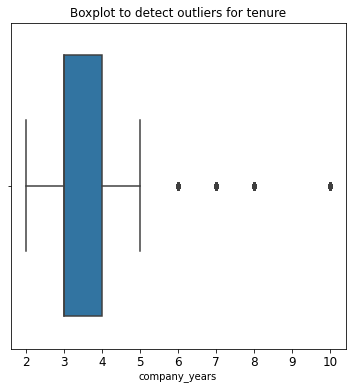

In [11]:
plt.figure(figsize=(6,6))
plt.title('Boxplot to detect outliers for tenure', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.boxplot(x=df1['company_years'])
plt.show()


Since there do seem to be outliers for the tenure variable of this data, I want to find out how many rows in the data contain such outliers.

In [12]:
percentile25 = df1['company_years'].quantile(0.25)

percentile75 = df1['company_years'].quantile(0.75)

iqr = percentile75 - percentile25


upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print('Lower limit:', lower_limit)
print('Upper limit:', upper_limit)

outliers = df1[(df1['company_years'] > upper_limit) | (df1['company_years'] < lower_limit)]

print("Number of rows in 'company_years' with outliers:", len(outliers))

Lower limit: 1.5
Upper limit: 5.5
Number of rows in 'company_years' with outliers: 824


## More in-depth Data Exploration

Now that the data has been cleaned and organized, I can start to ask more thorough questions about the data as it pertains to my original task. I want to understanding how many employees left the company, and ask myself, "What percentage of all employees does this figure represent?"

In [13]:
print(df1['left'].value_counts())
print()



print(df1['left'].value_counts(normalize=True))

0    10000
1     1991
Name: left, dtype: int64

0    0.833959
1    0.166041
Name: left, dtype: float64


The first set of numbers are the actual values of each group of employee: Left vs. Stayed.

The second set are the percentages of those two groups.

### Data visualizations

To get oriented on what variables held some statistical significance, and to give me a valid starting line to begin solving the task at hand, I created a heat map that showed me variables in the data that had notable coorelation with one another, and went from there.

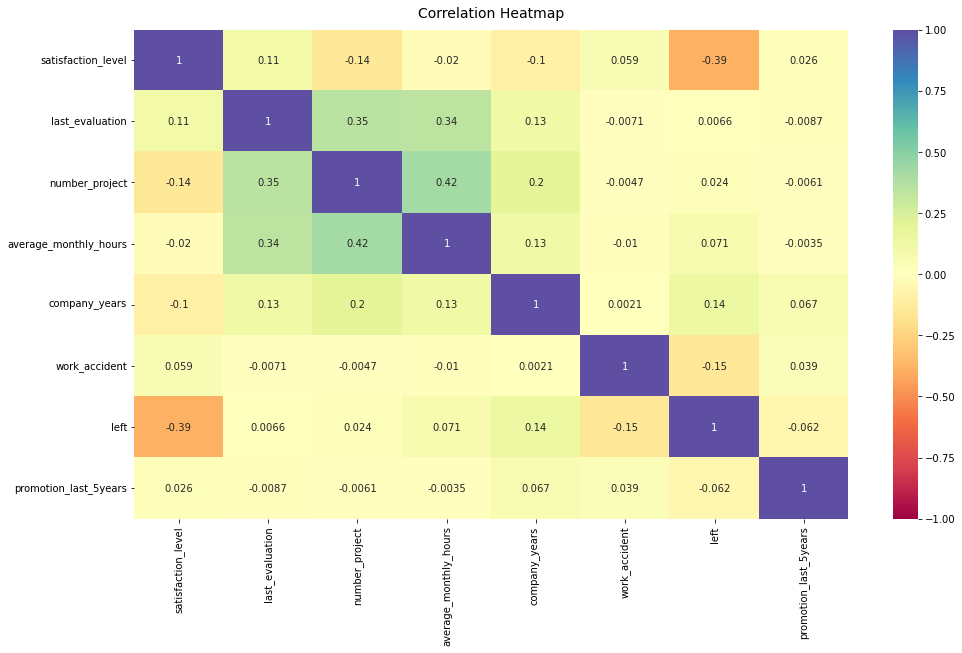

In [14]:
plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(df0.corr(), vmin=-1, vmax=1, annot=True, cmap=sns.color_palette("Spectral", as_cmap=True))
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12);

From this heat map, I now know that average_monthly_hours, number_projects, and last_evaluation are all notably positively coorelated, and that satisfaction_level, and left are notably negatively coorelated. 

Based off of this information, I now know what variables to start digging into to find answeres to my assigned task.

I decided to start looking into the coorelations between average_monthly_hours and number_projects first.

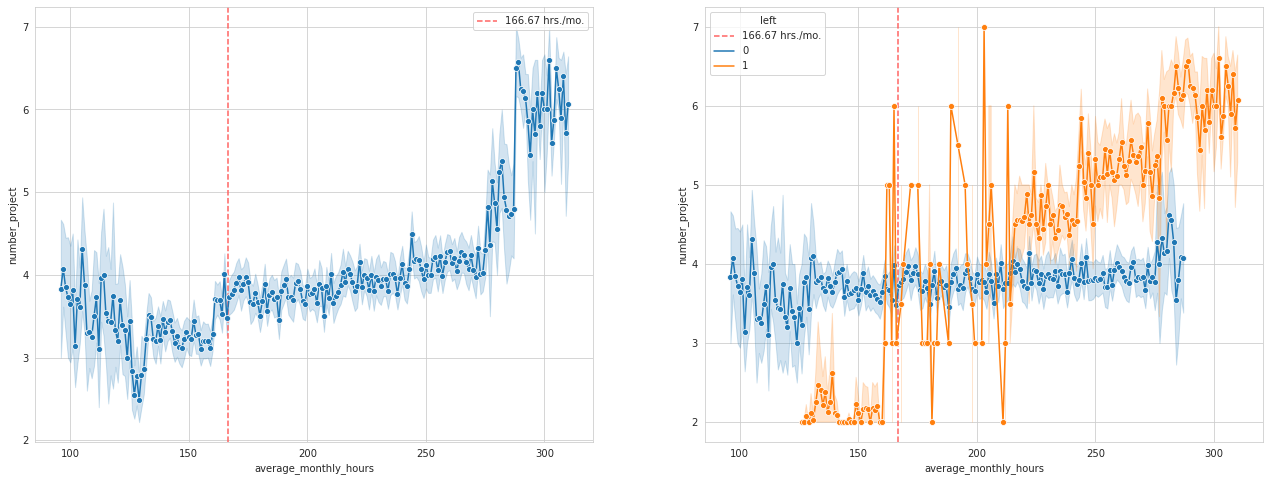

In [15]:
sns.set_style('whitegrid')

fig, ax = plt.subplots(1, 2, figsize=(22,8))

ax[0].axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
sns.lineplot(data = df1, x = 'average_monthly_hours', y = 'number_project', marker = 'o', ax=ax[0])

ax[1].axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
sns.lineplot(data = df1, x = 'average_monthly_hours', y = 'number_project', marker = 'o', hue='left', ax=ax[1])

For these two graphs, as well as all that follow, the red, dotted, vertical line represents the average 40 hour work week, which is aproximately 167 hours per month.

The graph on the left shows a simple distribution between hours worked and the number of projects an employee was working on. Noticably, the majority of employees are assigned about 4 projects at a time, but the majority of them are working far more than the average 40 hours a week. Once the number of projects assigned gets to 5, people are working around 275 hours a month, or likely far more.

The graph on the right shows the same distribution between hours worked per month and projects assigned, but now the data is also split between employees that stayed (blue), and employees that left (orange).

Notice the variance on the right side of both graphs. It is evident that 4 projects assigned at any given time is managable for most employees, but once more projects than 4 are assigned, employees most likely become unhappy with the workload and the amount of hours required to work and leave. The right graph aso shows that just about every employee assigned 5 projects or more left the company, and every employee assigned 7 or more did leave.

Text(0.5, 1.0, 'Monthly hours by number of projects')

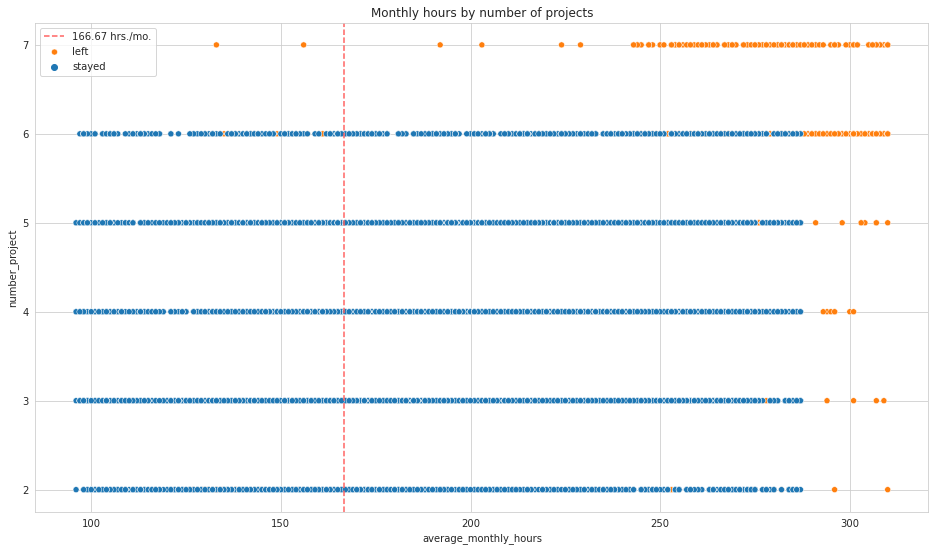

In [16]:
sns.set_style('whitegrid')
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='number_project', hue='left')
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by number of projects')

This graph futher demonstrates that once employees work over roughly 285 hours a month, they all leave, and that when assigned 7 or more projects at a time, they also all leave.

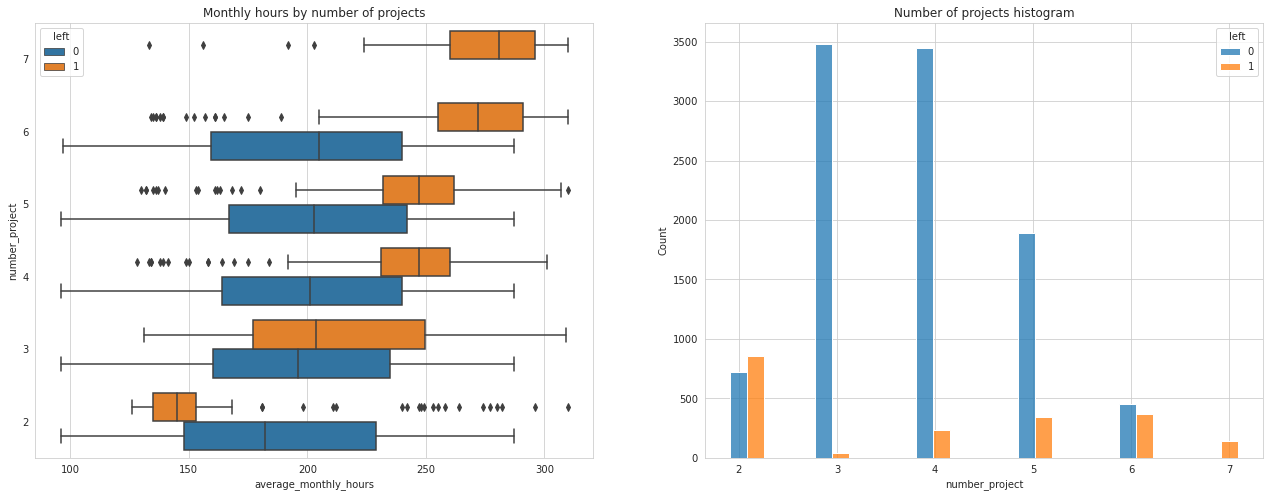

In [17]:
sns.set_style("whitegrid")

fig, ax = plt.subplots(1, 2, figsize = (22,8))

sns.boxplot(data=df1, x='average_monthly_hours', y='number_project', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by number of projects')

number_project_stay = df1[df1['left']==0]['number_project']
number_project_left = df1[df1['left']==1]['number_project']
sns.histplot(data=df1, x='number_project', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of projects histogram')

plt.show()

The left graph here shows a box and whisker plot of average monthly hours and number of projects. Notably, this graph shows that as more projects are assigned to employees, the greater the desparity between the average amount of average hours worked grows between those that stayed and those that left. From this, I infer that the employees who had more projects assigned and left were unhappy with the hours worked moreso than the amount of projects, since many employees who were also assigned more projects stayed and worked less hours. Unfairness in workload designation seems to be a factor here.

However, the histogram on the right shows the actual proportions of employees who stayed vs. left, measured againts the number of projects assigned. This graph shows that the vast majority of the workforce of the company is assigned 3-5 projects, and are all happy enough to stay despite the growing requirement of work hours. Not only are very few employees assigned 6 or more projects, but the ones that are are far more liekly to leave, with 7 projects garaunteeing they will.

I believe that the amount of employees that leave with only being assigned 2 projects leave for a far larger variety of reasons than simply being overworked, since the box and whisker plot shows they work the least amount of average hours a month.

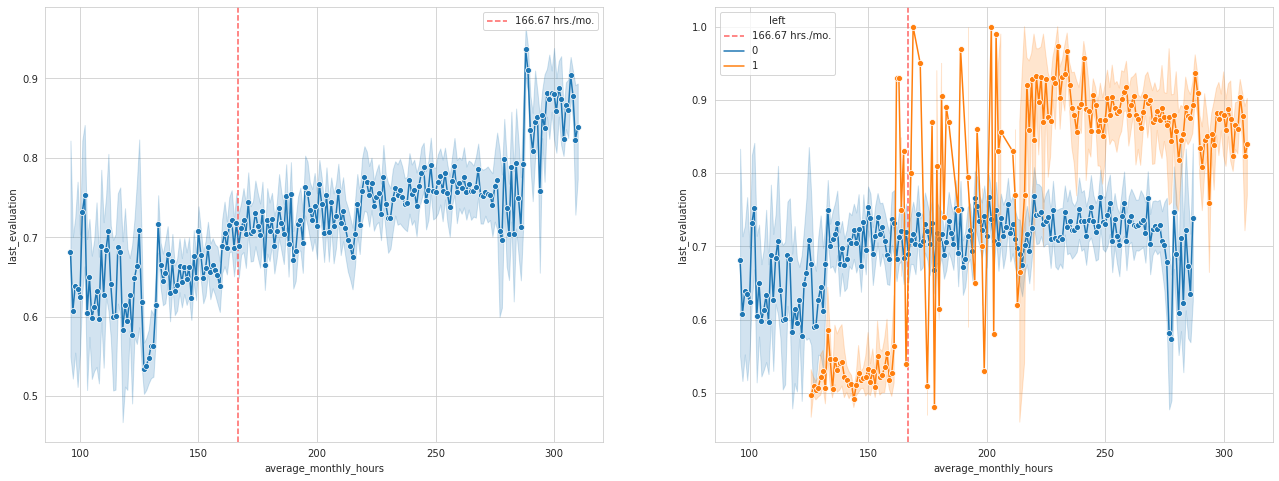

In [18]:
sns.set_style('whitegrid')

fig, ax = plt.subplots(1, 2, figsize=(22,8))

ax[0].axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
sns.lineplot(data = df1, x = 'average_monthly_hours', y = 'last_evaluation', marker = 'o', ax=ax[0])

ax[1].axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
sns.lineplot(data = df1, x = 'average_monthly_hours', y = 'last_evaluation', marker = 'o', hue='left', ax=ax[1])

After evaluating the coorelations between number of projects assigned and the average monthly work hours, I move on to the coorelations between the employees' last evaluation and their average monthly work hours.

The graph on the left shows a simple measure of every employee in the company, while the one the right shows a distribution of the same data between employees that stayed (blue), vs. left (orange).

To my own surprise, there is an overall positive trend between average monthly hours and the last evaluations, showing that as employees are given more work, they do better work overall.

To more of my surprise, the graph on the right shows that the employees that have better overall evaluations on their work are likely to be the ones that leave. 

Text(0.5, 1.0, 'Monthly hours by last evaluation score')

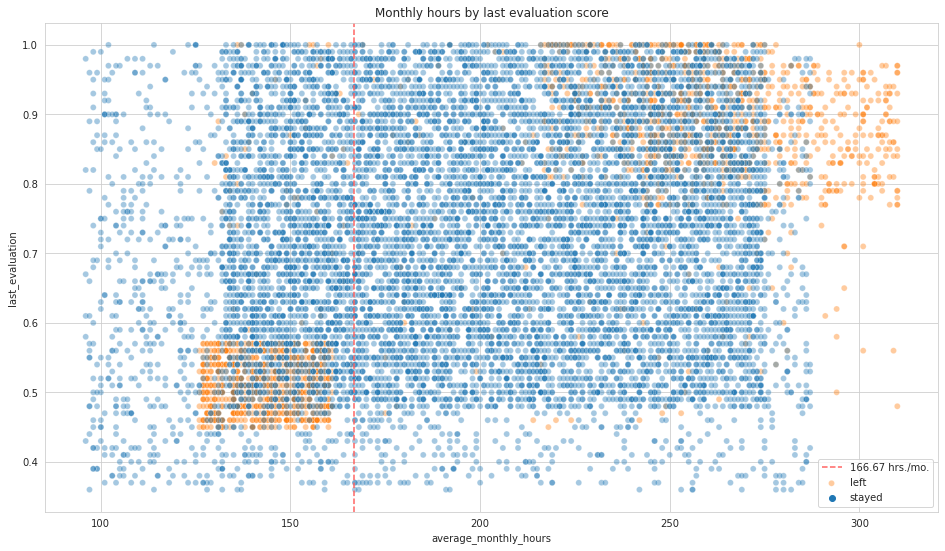

In [19]:
sns.set_style('whitegrid')
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='last_evaluation', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score')

This scatterplot of average monthly hours and last evalutation shows best the amount of employees at the company that work well over the average 40 hours per week routine.

This graph also shows well there are two main groups of employees who left: overworked employees that got high scores on their evaluations, and those who worked less than 40 hours a week and got poor evaluation scores.

It also shows that working long hours does not imply good evaluation scores.

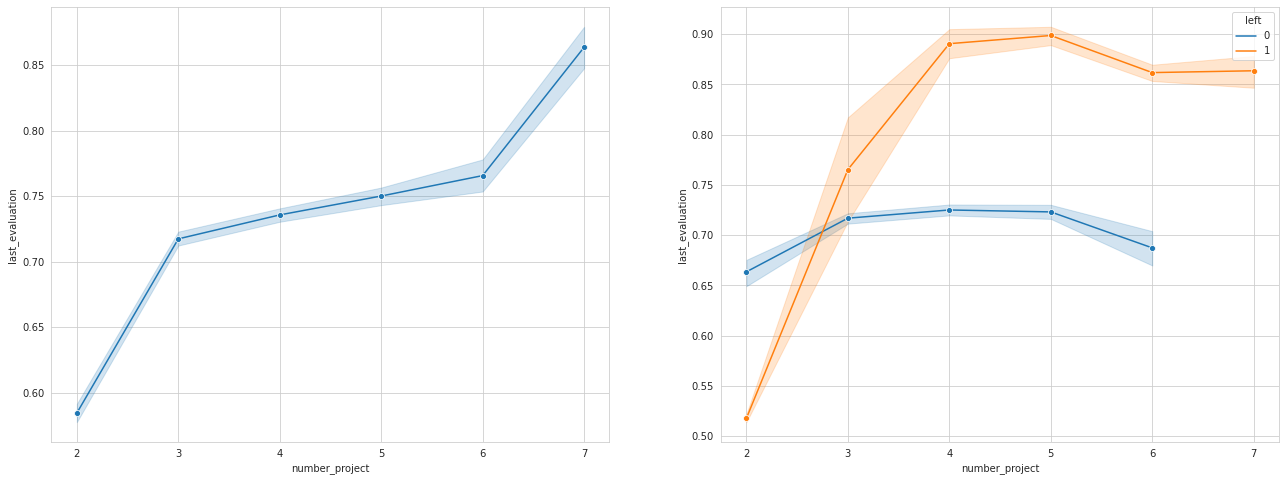

In [20]:
sns.set_style("whitegrid")

fig, ax = plt.subplots(1, 2, figsize=(22,8))
#plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
sns.lineplot(data = df1, x = 'number_project', y = 'last_evaluation', marker = 'o', ax=ax[0])


#plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
sns.lineplot(data = df1, x = 'number_project', y = 'last_evaluation', marker = 'o', hue='left', ax=ax[1])

Moving on to the coorelations between the number of projects and the last evaluations, the first graph on the left shows a simple line graph of all employees, while the one on the right shows the same data now distributed between those who wtayed (blue), vs. those who left (orange).

Much like average monthly hours and last evaluations, the left graph shows there is an positive trend between number of projects and last evaluations as well. This shows that as more projects are assigned, the better on average employees tend to be evaluated.

And when the data is split between those who left and stayed, the graph on the right shows that employees who were better evaluated and were assigned three or more projects left. Again, all employees assigned 7 projects left the company, but many employees who were evaluated the highest also left.

Based on the data in the last two graphs, I wanted to calculate the mean and median satisfaction scores for both the employees that stayed and left.

In [21]:
df1[df1['number_project']==7]['left'].value_counts()

1    145
Name: left, dtype: int64

In [22]:
df1.groupby(['left'])['satisfaction_level'].agg([np.mean,np.median])

,mean,median
left,,
0,0.667365,0.69
1,0.440271,0.41


As expected, based off the data of the graphs I've analyzed thus far, both the mean and median satisfaction scores of the employees who left were lower than of those who stayed. Notably, the average satisfaction score for those who stayed was lower than the median, meaning that even among the satisfied employees, it could still be better.

I decided to also measure satisfaction levels againts the other significant factors of average monthly hourse, and number of projects.

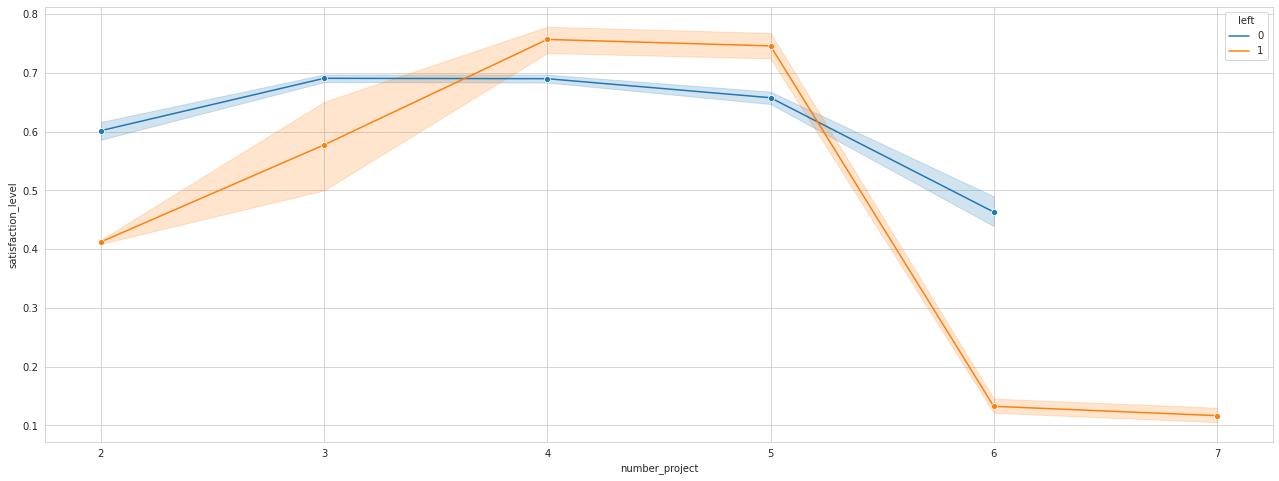

In [23]:
sns.set_style('whitegrid')
plt.figure(figsize=(22,8))
sns.lineplot(data=df1, x='number_project', y='satisfaction_level', marker='o', hue='left')

starting with the number of projects, there is a steep decline in satisfaction going from 5 to 6 projects assigned for those employees that left, and a slightly less extreme declien for those that stayed.

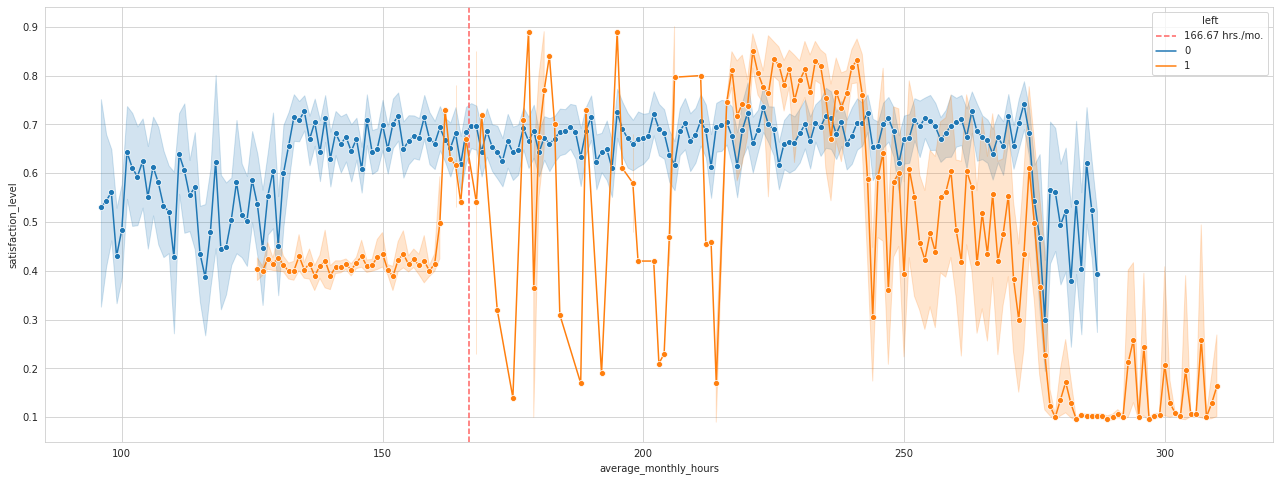

In [24]:
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(22,8))
ax.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
sns.lineplot(data=df1, x='average_monthly_hours', y='satisfaction_level', marker='o', hue='left', ax=ax)

When comparing satisfaction levels to average monthly hours worked, the satisfaction of employees who left are much more varied than those who stayed. Notably, a large portion of employees who left were actually more satisfied than those who stayed whe working about 225 hours on average a month. After about 245 hours, satisfaction declines in those who left, and at roughly 275 hours a month satisfaction declines for everyone.

I then wanted to compared satisfaction levels to the amount of years employees spent at the company.

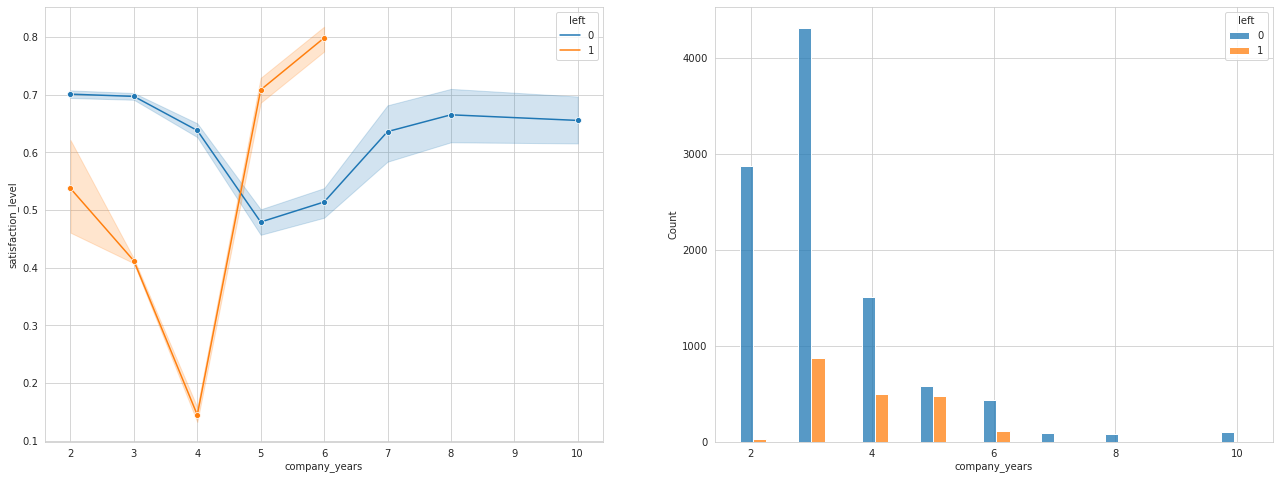

In [25]:
sns.set_style('whitegrid')

fig, ax = plt.subplots(1, 2, figsize=(22,8))

sns.lineplot(data=df1, x='company_years', y='satisfaction_level', marker='o', hue='left',ax=ax[0])

company_years_stay = df1[df1['left']==0]['company_years']
company_years_left = df1[df1['left']==1]['company_years']
sns.histplot(data=df1, x = 'company_years', hue = 'left', multiple = 'dodge', shrink = 5, ax=ax[1])

plt.show()

The graph on the left shows the satisfaction of workers over a decade of employement, divided between those who stayed (blue), and those who left (orange). For the first 4 years, satisfaction falls for both groups, but surprisingly the satisfaction of those who left shot up higher than for those who stayed at 5 years. From 5 to 6 years satisfaction rises for both groups, but no employee who left stayed for more than 6 years. After 6 years, the satisfaction of employed workers rises up again and evens out, but never rises past satisfaction of the first year.

The histogram on the right shows the proportions of people who stayed vs. left with regards to years worked at the company.

These two graphs were rather confusing. Why would the group of employees who left be more satisfied than those who stayed? I thought of what other factors could influence satisfaction, and decided to look at the promotion_5_years statistic and measure it againts average monthly hours.

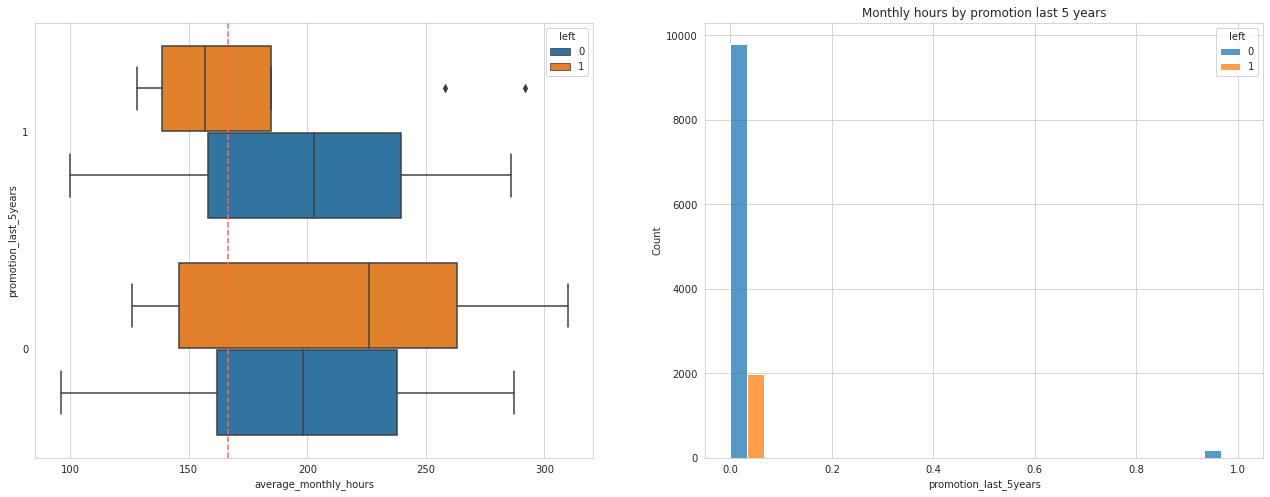

In [26]:
sns.set_style('whitegrid')

fig, ax = plt.subplots(1, 2, figsize=(22,8))
sns.boxplot(data=df1, x='average_monthly_hours', y='promotion_last_5years', hue='left', orient='h', ax=ax[0])
ax[0].invert_yaxis()
ax[0].axvline(x=166.67, color='#ff6361', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by promotion last 5 years')


promotion_last_5years_stay = df1[df1['left']==0]['promotion_last_5years']
promotion_last_5years_left = df1[df1['left']==1]['promotion_last_5years']
sns.histplot(data=df1, x='promotion_last_5years', hue='left', multiple='dodge', ax=ax[1])

plt.show()

The box and whisker plot on the left shows average monthly hours worked, split between thos who stayed vs. those who left, and also between weather each of those groups were promoted within the last 5 years (1), or not (0). For those who were not promoted, predictably, the ones who left were seemingly overworked compared to those who stayed. But surprisingly, for those that were promoted, the one who left worked less than those who stayed. This data indicates that a group of employees who left were also more satisfied than those who stayed, worked less hours, and were promoted.

This histogram to the right shows the proportions between those who were promoted (1) or not (0), and if they left (orange) or not (blue). Among all employees at the company, very few were actually promoted in the last 5 years, and of those that were promoted, very few left the company. The vast majority of the company was not promoted in the last 5 years.

### Insights

Based on the data shown from these graphs, it seems that employees leave the company ultimately due to poor management. Lost of projects assigned at once, vastly longer working hours than average, and low satisfaction scores seem to be leading indicators of an employee leaving. Working on so many different projects for so long without any promotions can make one feel both burnt out and unseen for their efforts. Its impracticale to expect anyone to want to stay in this kind of environment for long.

## Model Building

To boil down the task at hand, it is a matter of binary classification of catagorical outcomes. Will an employee leave? Yes, or no (1 or 0). Because of the nature of this problem, I opted to build a Tree-based Machine Learning Model to solve it.

### Modeling

I first created a copy of the data frame spicifically for modeling purposes, and named it 'df_tree'.

In [27]:
### YOUR CODE HERE ###
df_tree = df1.copy()

df_tree['salary'] = (df_tree['salary'].astype('category').cat
                    .set_categories(['low', 'medium', 'high']).cat.codes)


df_tree = pd.get_dummies(df_tree, drop_first=False)

df_tree.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,company_years,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,1,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0


I then singled out the outcome variable: 'left', and chose features to include in the model.

In [28]:
y = df_tree['left']

y.head()

0    1
1    1
2    1
3    1
4    1
Name: left, dtype: int64

In [29]:
X = df_tree.drop('left', axis=1)

X.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,company_years,work_accident,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,0,0,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,0,1,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,0,1,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,0,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,0,0,0,0,0,0,0,0,0,1,0,0


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

I then split the data into training, validating, and testing sets. 

In [31]:
TreeOG = DecisionTreeClassifier(random_state=0)

cv_params = {'max_depth': [4, 6, 8, None],
             'min_samples_leaf': [1, 2, 5],
             'min_samples_split': [2, 4, 6]
            }


scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}

Tree1 = GridSearchCV(TreeOG, cv_params, scoring=scoring, cv=4, refit = 'roc_auc')


I elected for the decicion tree and random forest model because it is the more exhaustive of the two methods, compared to a logistic regression model, in searching for the best model parameters in a cross-validating grid-search.

In [32]:
%%time

Tree1.fit(X_train, y_train)

CPU times: user 3 s, sys: 12.2 ms, total: 3.02 s
Wall time: 3.02 s


GridSearchCV(cv=4, error_score=nan,
             estimator=DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features=None,
                                              max_leaf_nodes=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              presort='deprecated',
                                              random_state=0, splitter='best'),
             iid='deprecated', n_jobs=None,
             param_grid={'max_depth': [4, 6, 8, None],
                         'min_samples_leaf': [1, 2, 5],
                

In [33]:
Tree1.best_params_

{'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}

In [34]:
Tree1.best_score_

0.969819392792457

These are the optimal values for the decision tree parameters, and the best AUC score the model achieved in the training set of data.

With such a strong AUC score, I am confident the model can accurately predict who will leave or stay.

Next, I create a function to output ALL scores from the grid-search.

In [35]:
def make_results(model_name:str, model_object, metric:str):
    
    metric_dict = {'auc': 'mean_test_roc_auc',
                   'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy'
                  }
    
    cv_results = pd.DataFrame(model_object.cv_results_)
    
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]]
                                             .idxmax(), :]
    
    auc = best_estimator_results.mean_test_roc_auc
    precision = best_estimator_results.mean_test_precision
    recall = best_estimator_results.mean_test_recall
    f1 = best_estimator_results.mean_test_f1
    accuracy = best_estimator_results.mean_test_accuracy
    
    table = pd.DataFrame()
    table = pd.DataFrame({'model': [model_name],
                          'auc': [auc],
                          'precision': [precision],
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy]
                         })
    return table

In [36]:
Tree1_results = make_results('Decision Tree 1', Tree1, 'auc')
Tree1_results

,model,auc,precision,recall,f1,accuracy
0,Decision Tree 1,0.969819,0.914552,0.916949,0.915707,0.971978


All of these scores tell me the model performs well. Now, to avoid overfitting the data, I create a random forest model which ustlizes mutltiple trees, all of which do cross-validating grid-searches, and fit it to the training data.

In [37]:
ForestOG = RandomForestClassifier(random_state=0)

cv_params = {'max_depth': [3, 5, None],
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1, 2, 3],
             'min_samples_split': [2, 3, 4],
             'n_estimators': [300, 500]
            }

scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}

Forest1 = GridSearchCV(ForestOG, cv_params, scoring=scoring, cv = 4, refit='roc_auc')

In [38]:
%%time

Forest1.fit(X_train, y_train)

CPU times: user 9min 38s, sys: 1.06 s, total: 9min 39s
Wall time: 9min 39s


GridSearchCV(cv=4, error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators=100, n_jobs=None,...
                                              verbose=0, warm_start=False),
             iid='deprecated', n_jo

Then I specify a path to save the model.

In [39]:
path = '/home/jovyan/work/'

In [40]:
def write_pickle(path, model_object, save_as:str):
    
    with open(path + save_as + '.pickle', 'wb') as to_write:
        pickle.dump(model_object, to_write)

In [41]:
def read_pickle(path, saved_model_name:str):
    
    with open(path + saved_model_name + '.pickle', 'rb') as to_read:
        model = pickle.load(to_read)

    return model

In [42]:
write_pickle(path, Forest1, 'Forest1')

In [43]:
Forest1 = read_pickle(path, 'Forest1')

I then create functions to pickle the model, saving it to my specified pathway, and read it back in so I don't have to run the forest model every single time.

In [44]:
Forest1.best_score_

0.9804250949807172

In [45]:
Forest1.best_params_

{'max_depth': 5,
 'max_features': 1.0,
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 500}

These are the best AUC score acheived and optimal parameters found by the random forest model on the training set of data.

Next, I put the evaluation scores on the training set for both the singular decision tree and random forest models side by side to compare.

In [46]:
Forest1_results = make_results('Random Forest 1', Forest1, 'auc')
print(Tree1_results)
print(Forest1_results)

             model       auc  precision    recall        f1  accuracy
0  Decision Tree 1  0.969819   0.914552  0.916949  0.915707  0.971978
             model       auc  precision    recall        f1  accuracy
0  Random Forest 1  0.980425   0.950023  0.915614  0.932467  0.977983


Based off the scores of the random forest model outperforming the decision tree model on all aspects but one, and for the one to be 0.001 below, I am confident that the random forest model is the more acurate model to follow.

I now want to measure the final model againts the test set of data.

To do this, I create a function to give me all the scores from the model's predictions, and input the test set of data through the best performing model. Then I look at what it predicted.

In [47]:
def get_scores(model_name:str, model, X_test_data, y_test_data):
    
    preds = model.best_estimator_.predict(X_test_data)

    auc = roc_auc_score(y_test_data, preds)
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision], 
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy],
                          'AUC': [auc]
                         })
  
    return table

In [48]:
Forest1_test = get_scores('Forest1 test', Forest1, X_test, y_test)
Forest1_test

,model,precision,recall,f1,accuracy,AUC
0,Forest1 test,0.964211,0.919679,0.941418,0.980987,0.956439


These test scores are very similar to that of the training data scores, making me confident that the performance of the model on this data is how it will perform on new data.

This concludes a single round of decision tree and random forest models. I want to go through one more round, this time with models improved apon by means of feature engineering, as to try and further reduce the chance of data leakage into the the output scores of the model.

To this end, I remove the 'satisfaction_level' column and create a new one called 'overworked', defined as an employee working over 175 hours a month. Remember, the average 40 hour work week means about 167 hours a month. Once I have the column defined properly, I make it binary by reassigning it using a beelean mask.

In [49]:
df2 = df_tree.drop('satisfaction_level', axis=1)
df2.head()

,last_evaluation,number_project,average_monthly_hours,company_years,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
1,0.86,5,262,6,0,1,0,1,0,0,0,0,0,0,0,1,0,0
2,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0
3,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0


In [50]:
df2['overworked'] = df2['average_monthly_hours']

print('Max Hours:', df2['overworked'].max())
print('Min Hours:', df2['overworked'].min())

Max Hours: 310
Min Hours: 96


In [51]:
df2['overworked'] = (df2['overworked'] > 175).astype(int)

df2['overworked'].head()

0    0
1    1
2    1
3    1
4    0
Name: overworked, dtype: int64

Now that I have the overworked column, I remove the average_monthly_hours one.

In [52]:
df2 = df2.drop('average_monthly_hours', axis=1)

df2.head()

,last_evaluation,number_project,company_years,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,overworked
0,0.53,2,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
1,0.86,5,6,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1
2,0.88,7,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1
3,0.87,5,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1
4,0.52,2,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0


I now begin the same process as before by isolating the features and target variabls, and split the data into training and testing data for the model to learn and then predict on.

In [53]:
y = df2['left']

X = df2.drop('left', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

In [54]:
TreeOG2 = DecisionTreeClassifier(random_state=0)

cv_params = {'max_depth':[4, 6, 8, None],
             'min_samples_leaf': [1, 2, 5],
             'min_samples_split': [2, 4, 6]
             }

scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}

Tree2 = GridSearchCV(TreeOG2, cv_params, scoring=scoring, cv=4, refit='roc_auc')

In [55]:
%%time

Tree2.fit(X_train, y_train)

CPU times: user 2.47 s, sys: 10 µs, total: 2.47 s
Wall time: 2.47 s


GridSearchCV(cv=4, error_score=nan,
             estimator=DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features=None,
                                              max_leaf_nodes=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              presort='deprecated',
                                              random_state=0, splitter='best'),
             iid='deprecated', n_jobs=None,
             param_grid={'max_depth': [4, 6, 8, None],
                         'min_samples_leaf': [1, 2, 5],
                

In [56]:
Tree2.best_params_

{'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 6}

In [57]:
Tree2.best_score_

0.9586752505340426

Based on these best parameters and AUC score, the model behaves satifactorily.

In [58]:
Tree2_results = make_results('Decision Tree 2', Tree2, 'auc')
print(Tree1_results)
print(Tree2_results)

             model       auc  precision    recall        f1  accuracy
0  Decision Tree 1  0.969819   0.914552  0.916949  0.915707  0.971978
             model       auc  precision    recall        f1  accuracy
0  Decision Tree 2  0.958675   0.856693  0.903553  0.878882  0.958523


Comparing the output scores of the two Decision Tree models I have now done, the scores of the second model have fallen. Not only is this expected behavior, since less features were put into the model, but the scores are still adequate.

Now I create my second random forest model.

In [59]:
ForestOG2 = RandomForestClassifier(random_state=0)

cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }

scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}

Forest2 = GridSearchCV(ForestOG2, cv_params, scoring=scoring, cv = 4, refit='roc_auc')

In [60]:
%%time

Forest2.fit(X_train, y_train)

CPU times: user 7min 15s, sys: 1.07 s, total: 7min 16s
Wall time: 7min 16s


GridSearchCV(cv=4, error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='auto',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              n_estimators=100, n_jobs=None,...
                                              verbose=0, warm_start=False),
             iid='deprecated', n_jo

In [61]:
write_pickle(path, Forest2, 'Forest2')

In [62]:
Forest2 = read_pickle(path, 'Forest2')

In [63]:
Forest2.best_params_

{'max_depth': 5,
 'max_features': 1.0,
 'max_samples': 0.7,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 300}

In [64]:
Forest2.best_score_

0.9648100662833985

In [65]:
Forest2_results = make_results('Random Forest 2', Forest2, 'auc')
print(Tree2_results)
print(Forest2_results)

             model       auc  precision    recall        f1  accuracy
0  Decision Tree 2  0.958675   0.856693  0.903553  0.878882  0.958523
             model      auc  precision    recall        f1  accuracy
0  Random Forest 2  0.96481   0.866758  0.878754  0.872407  0.957411


Comparing the output scores of the second round of models shows that the scores dropped slightly for both, but the AUC score for the random forest model can be used as the deciding metric.

Next, I use the test set of data.

In [66]:
Forest2_test = get_scores('Forest2 test', Forest2, X_test, y_test)
Forest2_test

,model,precision,recall,f1,accuracy,AUC
0,Forest2 test,0.870406,0.903614,0.8867,0.961641,0.938407


Bosed on these scores, I am confident the model is stable and trustworthy.

I use a confusion matrix to help me visualize how well the model actually predicts weather someont will stay or leave on the test set of data.

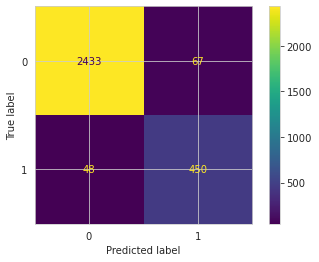

In [67]:
preds = Forest2.best_estimator_.predict(X_test)
cm = confusion_matrix(y_test, preds, labels=Forest2.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=Forest2.classes_)
disp.plot(values_format='')

This confusion matrix explains that the model has a better time predicting false positives than false negatives, meaning that employees who have no intention of leaving might be labeled as so. Non the less, the actual size of the numbers telles me its still a strong model.

I want to measure the importance of the features that each model took into consideration, so I first create a list of them all with the highest measured importance at the top, then turn that table into barplots to better visualize the data.

In [68]:
Tree2_importances = pd.DataFrame(Tree2.best_estimator_.feature_importances_, 
                                 columns=['gini_importance'], 
                                 index=X.columns
                                )
Tree2_importances = Tree2_importances.sort_values(by='gini_importance', ascending=False)

Tree2_importances = Tree2_importances[Tree2_importances['gini_importance'] != 0]
Tree2_importances

,gini_importance
last_evaluation,0.343958
number_project,0.343385
company_years,0.215681
overworked,0.093498
department_support,0.001142
salary,0.000910
department_sales,0.000607
department_technical,0.000418
work_accident,0.000183
department_IT,0.000139


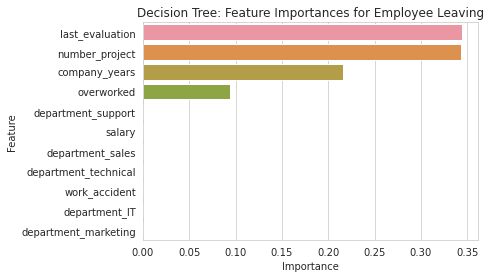

In [69]:
sns.barplot(data=Tree2_importances, x="gini_importance", y=Tree2_importances.index, orient='h')
plt.title("Decision Tree: Feature Importances for Employee Leaving", fontsize=12)
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.show()

For the decision tree model, 'last_evaluation', 'number_project', 'company_years', and 'overworked' are the most important variables it takes into consideration when predicting if someone will leave or stay. 

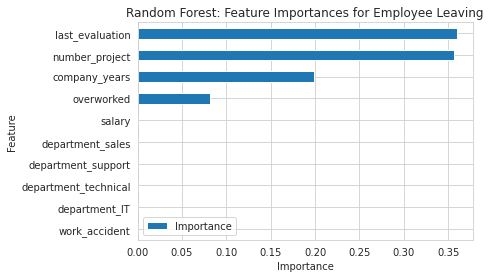

In [70]:
feat_impt = Forest2.best_estimator_.feature_importances_

ind = np.argpartition(Forest2.best_estimator_.feature_importances_, -10)[-10:]

feat = X.columns[ind]

feat_impt = feat_impt[ind]

y_df = pd.DataFrame({"Feature":feat,"Importance":feat_impt})
y_sort_df = y_df.sort_values("Importance")
fig = plt.figure()
ax1 = fig.add_subplot(111)

y_sort_df.plot(kind='barh',ax=ax1,x="Feature",y="Importance")

ax1.set_title("Random Forest: Feature Importances for Employee Leaving", fontsize=12)
ax1.set_ylabel("Feature")
ax1.set_xlabel("Importance")

plt.show()

The top 4 most important features in the decision tree model are also the top 4 most important features in the random forest model, and are in the exact same order as well.

## Results and Evaluation

In utilizing the Tree-based Machine Learning techniques and feature engineering strategies, the decision tree model came up with an AUC score of 93.8%, a precision score of 87%, a recall score of 90.4%, an f1-score of 88.7%, and an accuracy score of 96.2% on the test set of data, while the random forest model decently outperformed the decision tree model.

### Conclusion, Recommendations, Next Steps

Based on my EDA, data visualizations, and machine learning models, I believe it is safe to say the employees at this company are overworked. There are a number of things I can recommend the company do for more employee retention.

The company can put a limit on how many projects one person can be assigned to work on at a time. Consider promoting more employees sooner, or add a proportionate rewards scale for those who contribute more time and effort to the company as a means to incentivise employees to work harder if promotions are not possible or feasible. 

Making company policies on overtime pay and expectations around workload and time off more transparent, so the employees have absolute clarity on what is expected of them.

Have company-wide and within-team open comunications channels for a more collaborative work culture